In [11]:
from pathlib import Path
import sys

# Temporary path fix (we'll replace this later with pip install -e .)
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.loader import load_data

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
from src.data.loader import load_data
from src.data.preprocessing import (
    split_features_target,
    split_train_test,
    create_preprocessor,
)

df = load_data()

X, y = split_features_target(df)

X_train, X_test, y_train, y_test = split_train_test(X, y)

preprocessor = create_preprocessor()

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(type(X_train_processed))
print(X_train_processed.shape)

X_train_processed.head()

2026-07-11 13:21:20 | INFO | src.data.loader | Loading dataset...
2026-07-11 13:21:20 | INFO | src.data.loader | Dataset loaded successfully.
2026-07-11 13:21:20 | INFO | src.data.loader | Dataset shape: (303, 14)
2026-07-11 13:21:20 | INFO | src.data.loader | Missing values per column:
2026-07-11 13:21:20 | INFO | src.data.loader | age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
2026-07-11 13:21:20 | INFO | src.data.loader | Target distribution:
2026-07-11 13:21:20 | INFO | src.data.loader | target
0    164
1    139
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
(242, 28)


,num__age,num__trestbps,num__chol,num__thalach,num__oldpeak,cat__sex_0.0,cat__sex_1.0,cat__cp_1.0,cat__cp_2.0,cat__cp_3.0,...,cat__slope_1.0,cat__slope_2.0,cat__slope_3.0,cat__ca_0.0,cat__ca_1.0,cat__ca_2.0,cat__ca_3.0,cat__thal_3.0,cat__thal_6.0,cat__thal_7.0
180,-0.729485,-0.395692,0.458139,0.708371,-0.445445,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
208,0.050166,-0.054513,0.230598,0.222495,-0.891627,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
167,-0.061212,0.059213,0.723605,0.399178,-0.891627,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
105,-0.061212,-1.305501,1.121803,0.266666,-0.891627,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
297,0.272924,0.514117,-0.167601,-1.190962,-0.713154,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:20])

28
['num__age' 'num__trestbps' 'num__chol' 'num__thalach' 'num__oldpeak'
 'cat__sex_0.0' 'cat__sex_1.0' 'cat__cp_1.0' 'cat__cp_2.0' 'cat__cp_3.0'
 'cat__cp_4.0' 'cat__fbs_0.0' 'cat__fbs_1.0' 'cat__restecg_0.0'
 'cat__restecg_1.0' 'cat__restecg_2.0' 'cat__exang_0.0' 'cat__exang_1.0'
 'cat__slope_1.0' 'cat__slope_2.0']


In [4]:
print(X_train_processed.isnull().sum().sum())

0


In [5]:
from src.data.loader import load_data
from src.data.preprocessing import (
    create_preprocessor,
    split_features_target,
    split_train_test,
)
from src.models.train import (
    train_logistic_regression,
    train_random_forest,
)

df = load_data()

X, y = split_features_target(df)

X_train, X_test, y_train, y_test = split_train_test(X, y)

preprocessor = create_preprocessor()

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

lr_model = train_logistic_regression(
    X_train_processed,
    y_train,
)

rf_model = train_random_forest(
    X_train_processed,
    y_train,
)

print(type(lr_model))
print(type(rf_model))

2026-07-11 13:32:47 | INFO | src.data.loader | Loading dataset...
2026-07-11 13:32:47 | INFO | src.data.loader | Dataset loaded successfully.
2026-07-11 13:32:47 | INFO | src.data.loader | Dataset shape: (303, 14)
2026-07-11 13:32:47 | INFO | src.data.loader | Missing values per column:
2026-07-11 13:32:47 | INFO | src.data.loader | age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
2026-07-11 13:32:47 | INFO | src.data.loader | Target distribution:
2026-07-11 13:32:47 | INFO | src.data.loader | target
0    164
1    139
Name: count, dtype: int64


<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## Compare both models

In [15]:
from src.models.evaluate import (
    evaluate_model,
    plot_confusion_matrix,
)

lr_metrics = evaluate_model(
    lr_model,
    X_test_processed,
    y_test,
)

rf_metrics = evaluate_model(
    rf_model,
    X_test_processed,
    y_test,
)

results = pd.DataFrame(
    [lr_metrics, rf_metrics],
    index=["Logistic Regression", "Random Forest"],
)

results


Classification Report

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61


Classification Report

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.885246,0.83871,0.928571,0.881356,0.966450
Random Forest,0.868852,0.81250,0.928571,0.866667,0.942641


## Plot confusion matrix

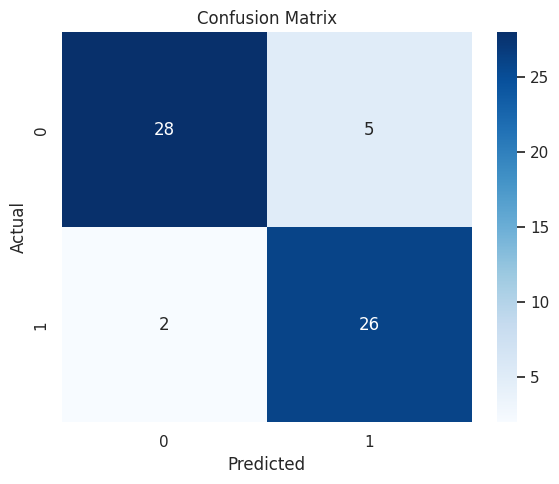

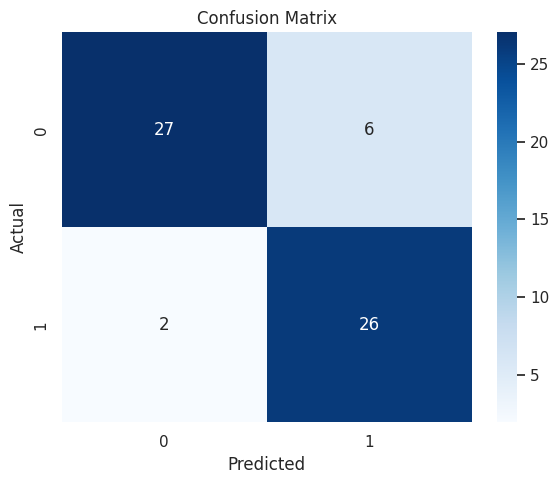

In [16]:
plot_confusion_matrix(
    lr_model,
    X_test_processed,
    y_test,
    "./reports/lr_confusion_matrix.png",
)

plot_confusion_matrix(
    rf_model,
    X_test_processed,
    y_test,
    "./reports/rf_confusion_matrix.png",
)

In [18]:
import importlib
import src.models.evaluate

importlib.reload(src.models.evaluate)

from src.models.evaluate import cross_validate_model

In [19]:
import src.models.evaluate as ev

print(dir(ev))

['Dict', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy_score', 'classification_report', 'confusion_matrix', 'cross_val_score', 'cross_validate_model', 'evaluate_model', 'f1_score', 'pd', 'plot_confusion_matrix', 'plt', 'precision_score', 'recall_score', 'roc_auc_score', 'sns']


# Test cross validation

In [20]:
cv_lr = cross_validate_model(
    train_logistic_regression(X_train_processed, y_train),
    X_train_processed,
    y_train,
)

cv_rf = cross_validate_model(
    train_random_forest(X_train_processed, y_train),
    X_train_processed,
    y_train,
)

print(cv_lr)
print(cv_rf)

{'Mean Accuracy': np.float64(0.8427721088435375), 'Std Accuracy': np.float64(0.05337156324529756)}
{'Mean Accuracy': np.float64(0.7975340136054421), 'Std Accuracy': np.float64(0.047838264846322275)}


Save comparision tale

In [22]:
results.to_csv("./reports/model_comparison.csv", index=True)

In [23]:
from src.models.tune import (
    tune_logistic_regression,
    tune_random_forest,
)

lr_search = tune_logistic_regression(
    X_train_processed,
    y_train,
)

rf_search = tune_random_forest(
    X_train_processed,
    y_train,
)

print("Best Logistic Regression:")
print(lr_search.best_params_)
print(lr_search.best_score_)

print()

print("Best Random Forest:")
print(rf_search.best_params_)
print(rf_search.best_score_)

Best Logistic Regression:
{'C': 10, 'solver': 'liblinear'}
0.8253186757781199

Best Random Forest:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
0.7882997353169244


In [24]:
best_lr = lr_search.best_estimator_
best_rf = rf_search.best_estimator_

lr_metrics = evaluate_model(
    best_lr,
    X_test_processed,
    y_test,
)

rf_metrics = evaluate_model(
    best_rf,
    X_test_processed,
    y_test,
)


Classification Report

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


Classification Report

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [25]:
import pandas as pd

comparison = pd.DataFrame(
    [lr_metrics, rf_metrics],
    index=[
        "Tuned Logistic Regression",
        "Tuned Random Forest",
    ],
)

comparison

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Tuned Logistic Regression,0.868852,0.833333,0.892857,0.862069,0.962121
Tuned Random Forest,0.868852,0.812500,0.928571,0.866667,0.950216


In [26]:
comparison.to_csv(
    "./reports/tuned_model_comparison.csv"
)

## Save best model

In [28]:
from src.models.save_model import save_model

save_model(
    best_rf,
    "./models/best_model.pkl",
)

## save the fitted preprocessor

In [29]:
import joblib

joblib.dump(
    preprocessor,
    "./models/preprocessor.pkl",
)

['./models/preprocessor.pkl']

In [30]:
from src.models.mlflow_utils import log_experiment

log_experiment(
    model_name="Random Forest",
    model=best_rf,
    metrics=rf_metrics,
    params=rf_search.best_params_,
)

2026/07/11 15:12:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/11 15:12:36 INFO mlflow.store.db.utils: Updating database tables
2026/07/11 15:12:37 INFO mlflow.tracking.fluent: Experiment with name 'Heart Disease Prediction' does not exist. Creating a new experiment.
2026/07/11 15:12:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [32]:
import mlflow
mlflow.log_artifact("./reports/tuned_model_comparison.csv")

In [33]:
mlflow.log_artifact("./reports/lr_confusion_matrix.png")
mlflow.log_artifact("./reports/rf_confusion_matrix.png")